In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

from myDataset import *
from ArchitectureMethods import *
from MetricMethods import *

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cpu.manual_seed = seed
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
print(os.getcwd())
os.chdir("..")
print(os.getcwd())
train_dataset = myDataset(directory = "DATASET/train", transform = train_transform)
val_dataset = myDataset(directory = "DATASET/validation", transform = val_transform)
test_dataset = myDataset(directory = "DATASET/test", transform = test_transform)

print(f'Train set length: '+ str(len(train_dataset)))
print(f'Test set length: '+ str(len(val_dataset)))
print(f'Validation set length: '+ str(len(test_dataset)))

train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True, num_workers= 8 )
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False, num_workers= 8)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False, num_workers= 8)


/user/HS401/ob00564/Documents/COM3001/KDEF/Transfer Learning
/user/HS401/ob00564/Documents/COM3001/KDEF
Train set length: 2350
Test set length: 294
Validation set length: 294


In [ ]:
sorted_emotion_counts = train_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = val_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = test_dataset.getNoImagesInClass()
print(sorted_emotion_counts)

{'0': 336, '1': 336, '2': 336, '3': 336, '4': 335, '5': 335, '6': 336}
{'0': 42, '1': 42, '2': 42, '3': 42, '4': 42, '5': 42, '6': 42}
{'0': 42, '1': 42, '2': 42, '3': 42, '4': 42, '5': 42, '6': 42}
/user/HS401/ob00564/Documents/COM3001/KDEF


In [4]:
import torchvision.models as models
emotionTotal = 7
myModel = models.mobilenet_v2(weights = 'DEFAULT')
myModel.classifier = torch.nn.Linear(in_features=1280, out_features= 7)
print(myModel)
# Freeze all layers
for param in myModel.parameters():
    param.requires_grad = False

# Unfreeze classifer layer
for param in myModel.classifier.parameters():
    param.requires_grad = True

# # Unfreeze 16th, 17th, 18th layers
# for id in range(16,19):
#     for param in myModel.features[id].parameters():
#         param.requires_grad = True
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
myModel.to(device)
print(device)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [ ]:
import copy
# @title Training Loop
from tqdm import tqdm
# Loss function 
criterion = nn.CrossEntropyLoss()

# Optimizer
# optimizer = optim.SGD(myModel.parameters(), lr = 0.00001, momentum=0.96, weight_decay= 0.1)
optimizer = optim.Adam(myModel.parameters(), lr = 0.00001, weight_decay=0.01)
train_losses, val_losses, train_accuracy, val_accuracy = train(myModel, device, train_loader, val_loader, optimizer, None, 100, criterion, 'KDEF/Transfer Learning/KDEF MobileNetV2 copy.pth')

100%|██████████| 147/147 [00:57<00:00,  2.54it/s]


Epoch 1/100, Training Loss: 1.9638, Validation Loss: 1.9499
Epoch 1/100, Training Acc: 13.77551020408163, Validation Accuracy: 16.00877192982456


100%|██████████| 147/147 [00:01<00:00, 76.92it/s]


Epoch 2/100, Training Loss: 1.9537, Validation Loss: 1.9447
Epoch 2/100, Training Acc: 13.90913508260447, Validation Accuracy: 15.021929824561402


100%|██████████| 147/147 [00:01<00:00, 76.28it/s]


...

Epoch 98/100, Training Loss: 1.5461, Validation Loss: 1.5645
Epoch 98/100, Training Acc: 53.468172983479114, Validation Accuracy: 55.70175438596492


100%|██████████| 147/147 [00:02<00:00, 72.59it/s]


Epoch 99/100, Training Loss: 1.5392, Validation Loss: 1.5672
Epoch 99/100, Training Acc: 53.917638483965014, Validation Accuracy: 55.26315789473685


100%|██████████| 147/147 [00:02<00:00, 72.18it/s]


Epoch 100/100, Training Loss: 1.5431, Validation Loss: 1.5836
Epoch 100/100, Training Acc: 54.51287657920311, Validation Accuracy: 58.00438596491229
Model saved successfully!


In [6]:
y_true, y_pred, y_score = test(myModel, device, criterion, test_loader, 'Test')

Test Loss: 1.6145, Test Accuracy: 48.30%


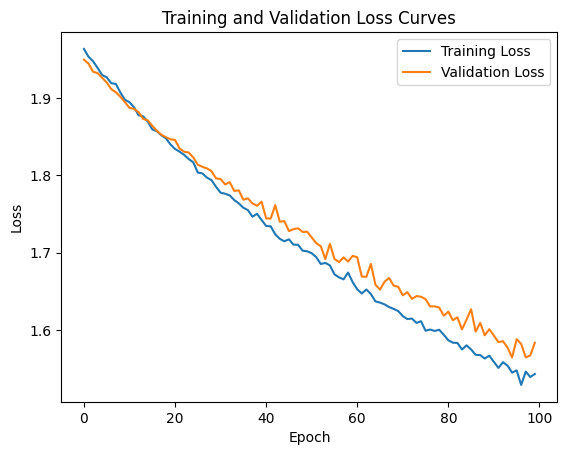

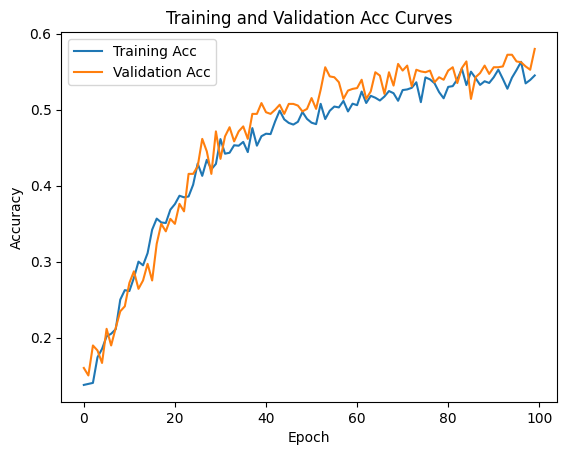

              precision    recall  f1-score   support

       Anger     0.5102    0.5952    0.5495        42
     Disgust     0.3958    0.4524    0.4222        42
        Fear     0.4000    0.1905    0.2581        42
   Happiness     0.7273    0.7619    0.7442        42
     Sadness     0.3793    0.2619    0.3099        42
    Surprise     0.5102    0.5952    0.5495        42
     Neurtal     0.4000    0.5238    0.4536        42

    accuracy                         0.4830       294
   macro avg     0.4747    0.4830    0.4695       294
weighted avg     0.4747    0.4830    0.4695       294



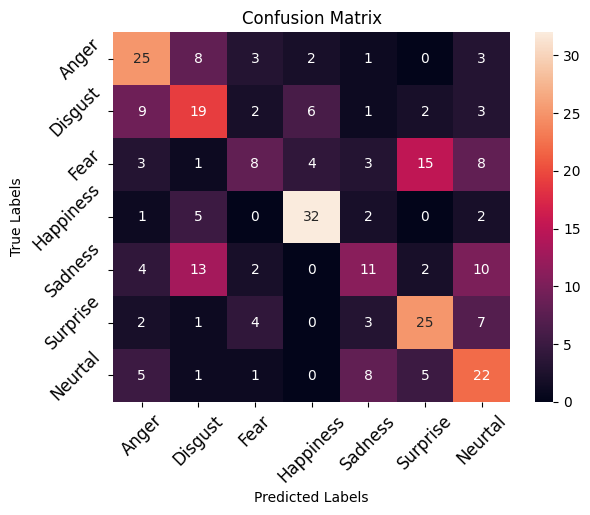

In [7]:
lossPlot(train_losses, val_losses)
accuracyPlot(train_accuracy, val_accuracy)
confusionMatrixPlot(y_true, y_pred)